In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans


In [5]:
df=pd.read_csv('customer_segmentation.csv')
#displaying the first 5 rows of the dataset
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [7]:
#looking for the missing values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [8]:
#cleaning the dataset by dropping the missing values
df.dropna(inplace=True)
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64 

In [11]:
#unique values
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [12]:
df.drop(columns=['Z_CostContact','Z_Revenue'],inplace=True)

In [15]:
df['MntTotal']=(
    df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']
)
df[['MntTotal']].head()

,MntTotal
0,1617
1,27
2,776
3,53
4,422


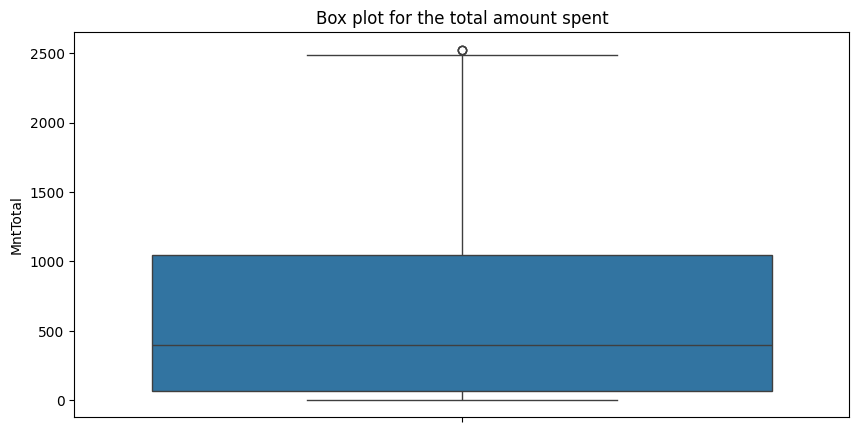

In [16]:
#box plot for the total amnt spent(MntTotal)
plt.figure(figsize=(10,5))
sns.boxplot(df['MntTotal'])
plt.title('Box plot for the total amount spent')
plt.show()

In [17]:
print("""
The box plot helps identify spending distribution and potential outliers.
Customers with unusually high spending appear above the upper whisker,
indicating premium or high-value customers.
""")


The box plot helps identify spending distribution and potential outliers.
Customers with unusually high spending appear above the upper whisker,
indicating premium or high-value customers.



In [18]:
Q1 = df['MntTotal'].quantile(0.25)
Q3 = df['MntTotal'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['MntTotal'] < lower_bound) |
    (df['MntTotal'] > upper_bound)
]

print("Number of Outliers:", len(outliers))
outliers[['ID','MntTotal']].head()

Number of Outliers: 3


,ID,MntTotal
1179,5735,2525
1492,1763,2524
1572,5350,2525


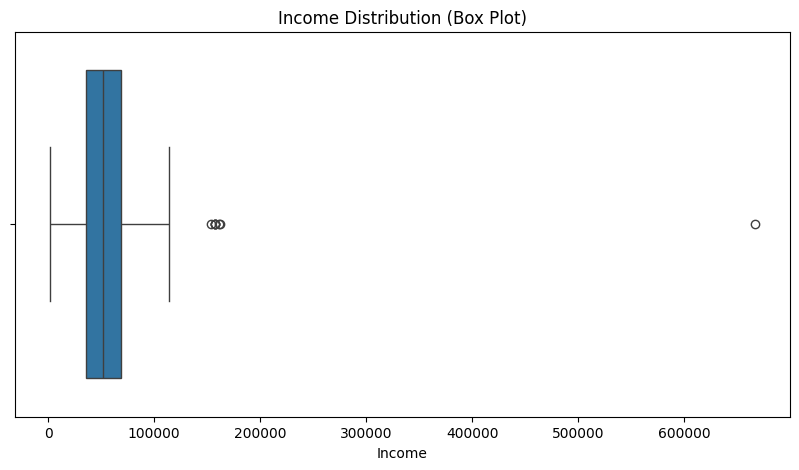

In [21]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Income'])

plt.title("Income Distribution (Box Plot)")

plt.show()

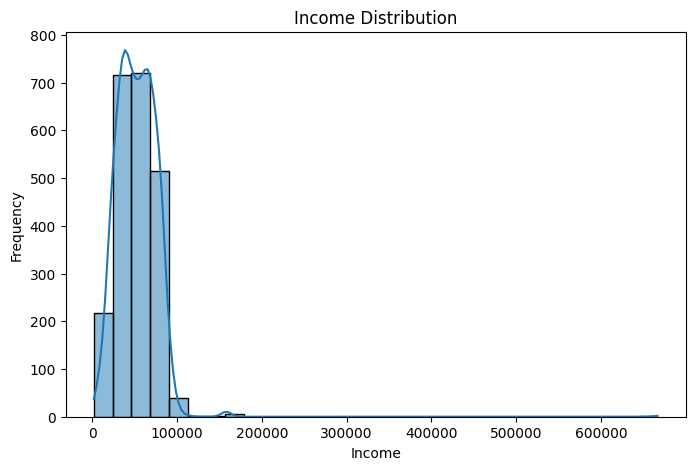

In [22]:
#histogram for income
plt.figure(figsize=(8,5))

sns.histplot(
    df['Income'],
    bins=30,
    kde=True
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

In [24]:
df['Age'] = 2026 - df['Year_Birth']
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,MinTotal,MntTotal,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,0,1,1617,1617,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,0,0,27,27,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,0,0,776,776,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,0,0,53,53,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,0,0,422,422,45


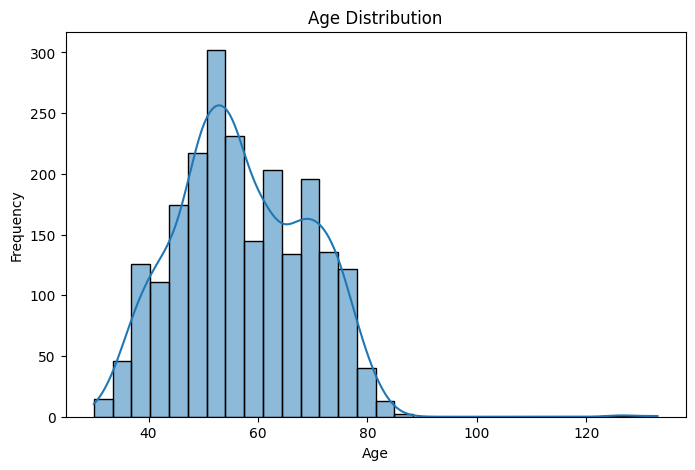

In [25]:
#histogram for age
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

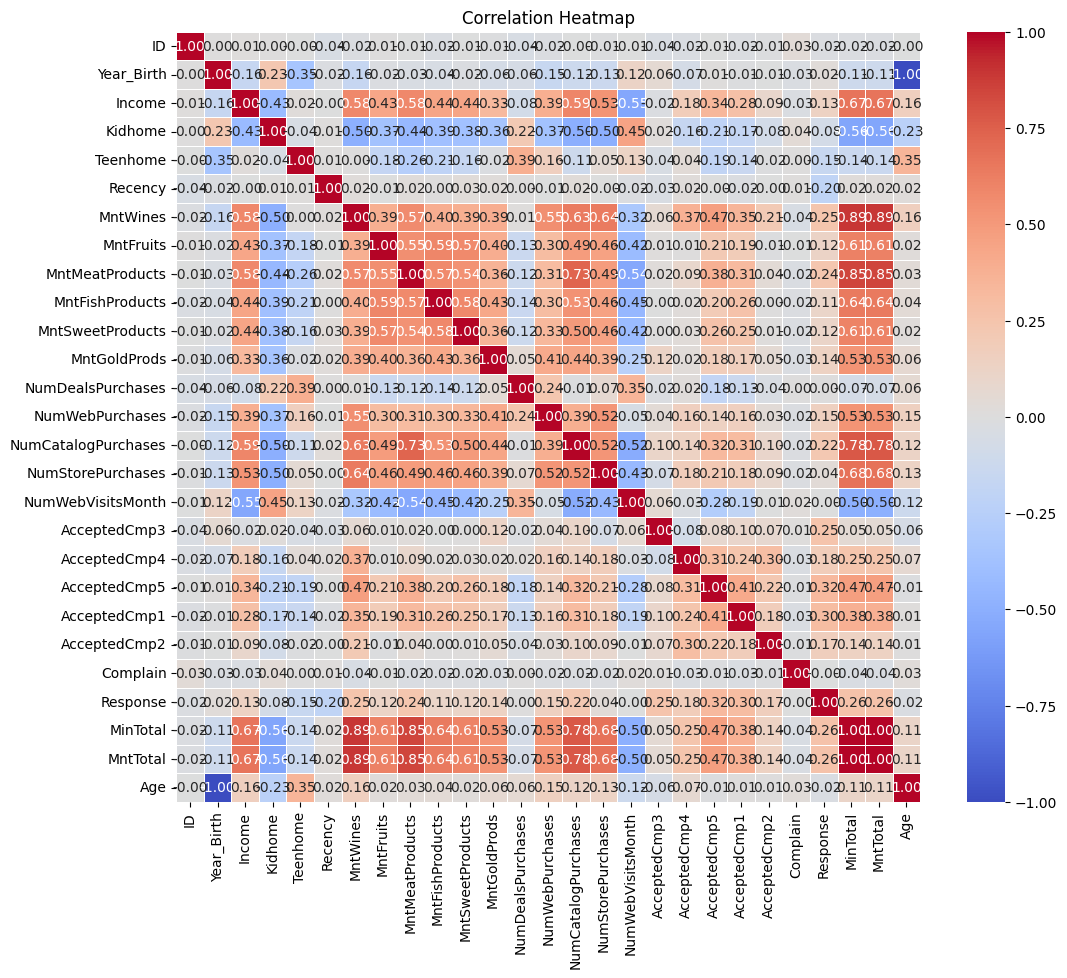

In [27]:
#correlation 
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

corr_matrix
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")    
plt.show()

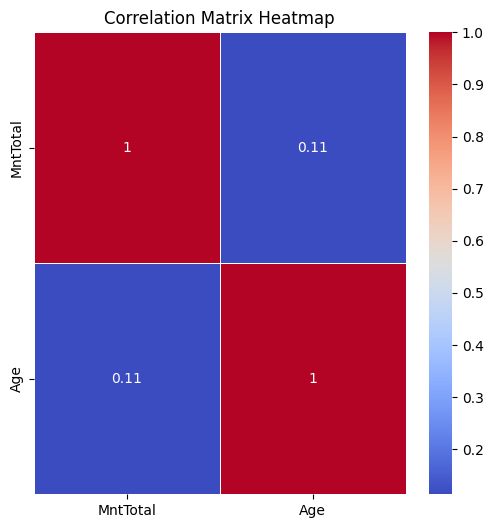

In [34]:
#correlation between age and total amount spent
corr_matrix = df[['MntTotal']+['Age']].corr()
plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [29]:
corr_matrix['MntTotal'].sort_values(ascending=False)

MinTotal               1.000000
MntTotal               1.000000
MntWines               0.893136
MntMeatProducts        0.845884
NumCatalogPurchases    0.780482
NumStorePurchases      0.675181
Income                 0.667576
MntFishProducts        0.642371
MntFruits              0.613249
MntSweetProducts       0.607062
NumWebPurchases        0.528973
MntGoldProds           0.528708
AcceptedCmp5           0.470278
AcceptedCmp1           0.380825
Response               0.264127
AcceptedCmp4           0.248805
AcceptedCmp2           0.136161
Age                    0.113487
AcceptedCmp3           0.053041
Recency                0.020066
ID                    -0.017052
Complain              -0.037428
NumDealsPurchases     -0.065854
Year_Birth            -0.113487
Teenhome              -0.138153
NumWebVisitsMonth     -0.499082
Kidhome               -0.557899
Name: MntTotal, dtype: float64

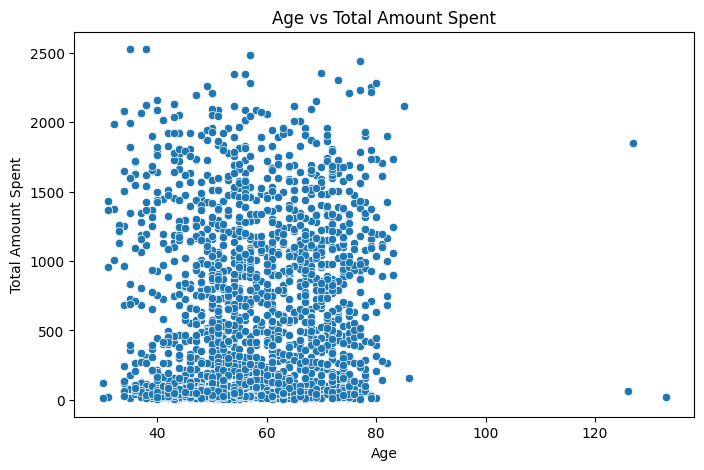

In [28]:
#correlation between age and total amount spent
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Age'], y=df['MntTotal'])  
plt.title("Age vs Total Amount Spent")
plt.xlabel("Age")   
plt.ylabel("Total Amount Spent")
plt.show()

In [30]:
from scipy.stats import pointbiserialr

binary_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Complain',
    'Response'
]

results = []

for col in binary_cols:

    corr, p_value = pointbiserialr(
        df[col],
        df['MntTotal']
    )

    results.append([col, corr, p_value])

pb_corr = pd.DataFrame(
    results,
    columns=['Variable','Correlation','P_Value']
)

pb_corr.sort_values(
    by='Correlation',
    ascending=False
)

,Variable,Correlation,P_Value
4,AcceptedCmp5,0.470278,2.447929e-122
0,AcceptedCmp1,0.380825,2.081631e-77
6,Response,0.264127,1.091325e-36
3,AcceptedCmp4,0.248805,1.283164e-32
1,AcceptedCmp2,0.136161,1.226014e-10
2,AcceptedCmp3,0.053041,1.251701e-02
5,Complain,-0.037428,7.815279e-02


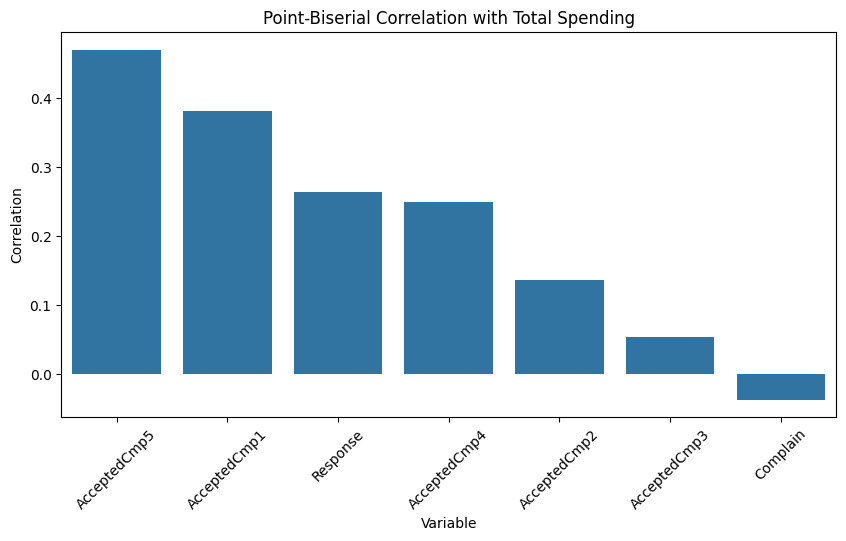

In [31]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=pb_corr.sort_values(
        by='Correlation',
        ascending=False
    ),
    x='Variable',
    y='Correlation'
)

plt.title(
    "Point-Biserial Correlation with Total Spending"
)

plt.xticks(rotation=45)

plt.show()


In [52]:
df['Marital_Status'].replace({
    'Married': 'Married',
    'Together': 'Married',
    'Single': 'Single',
    'Divorced': 'Single'
    
})

0        Single
1        Single
2       Married
3       Married
4       Married
         ...   
2235    Married
2236    Married
2237     Single
2238    Married
2239    Married
Name: Marital_Status, Length: 2216, dtype: object

In [ ]:
# 1 refers to married
# 0 refers to single


df['In_relationship'] = df['Marital_Status'].isin(
    ['Married', 'Together']
).astype(int)

In [57]:
df['In_relationship'].value_counts()

In_relationship
1    1430
0     786
Name: count, dtype: int64

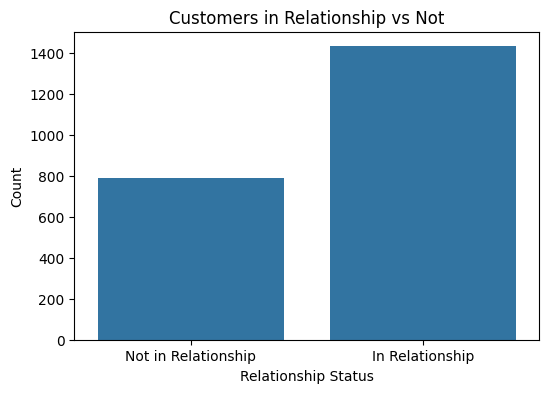

In [58]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='In_relationship',
    data=df
)

plt.title("Customers in Relationship vs Not")

plt.xlabel("Relationship Status")
plt.ylabel("Count")

plt.xticks(
    [0,1],
    ['Not in Relationship', 'In Relationship']
)

plt.show()

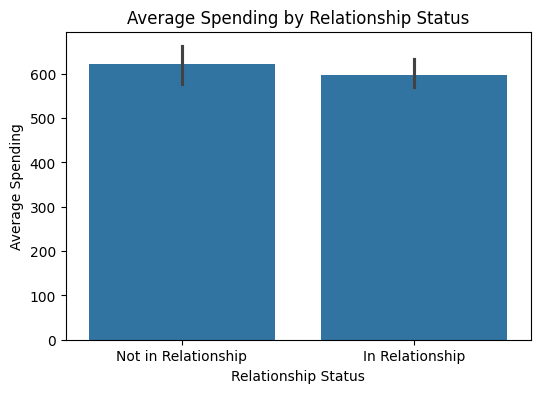

In [61]:
#toatal spending by relationship status

relationship_spending = df.groupby('In_relationship')['MntTotal'].mean()
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x='In_relationship',
    y='MntTotal'
)

plt.title("Average Spending by Relationship Status")

plt.xlabel("Relationship Status")
plt.ylabel("Average Spending")

plt.xticks(
    [0,1],
    ['Not in Relationship', 'In Relationship']
)

plt.show()

In [35]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'MinTotal', 'MntTotal', 'Age'],
      dtype='object')

In [62]:
df['Total_Purchases'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)
# Total Children
df['Children'] = df['Kidhome'] + df['Teenhome']



In [63]:
features = df[
    [
        'Income',
        'Age',
        'MntTotal',
        'Total_Purchases',
        'Recency',
        'Children',
        'In_relationship'
    ]
]

features.head()

,Income,Age,MntTotal,Total_Purchases,Recency,Children,In_relationship
0,58138.0,69,1617,22,58,0,0
1,46344.0,72,27,4,38,2,0
2,71613.0,61,776,20,26,0,1
3,26646.0,42,53,6,26,1,1
4,58293.0,45,422,14,94,1,1


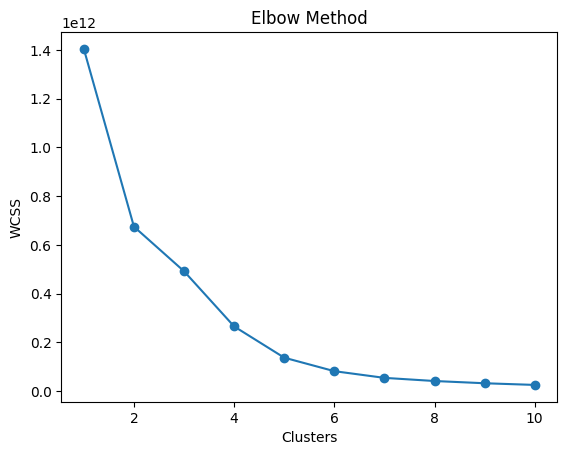

In [64]:


wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(features)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

In [65]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(features)

In [67]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    features
)
df['Cluster'].value_counts()

Cluster
2    786
1    742
0    687
3      1
Name: count, dtype: int64

In [68]:
cluster_summary = df.groupby(
    'Cluster'
)[
    [
        'Income',
        'Age',
        'MntTotal',
        'Total_Purchases',
        'Recency'
    ]
].mean()

cluster_summary.round(2)

,Income,Age,MntTotal,Total_Purchases,Recency
Cluster,,,,,
0,76967.84,58.57,1283.72,19.25,49.02
1,28364.25,52.90,94.82,5.76,48.59
2,52404.66,60.02,499.93,13.12,49.44
3,666666.00,49.00,62.00,7.00,23.00


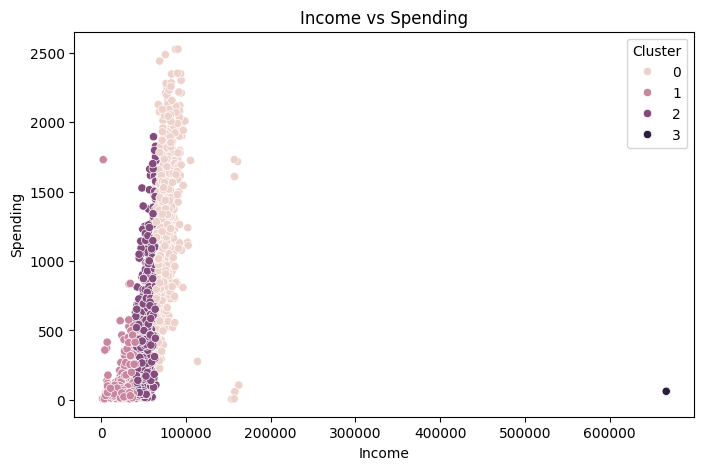

In [69]:
#income vs spending
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Income'],
    y=df['MntTotal'],
    hue=df['Cluster']
)

plt.title("Income vs Spending")
plt.xlabel("Income")
plt.ylabel("Spending")

plt.show()

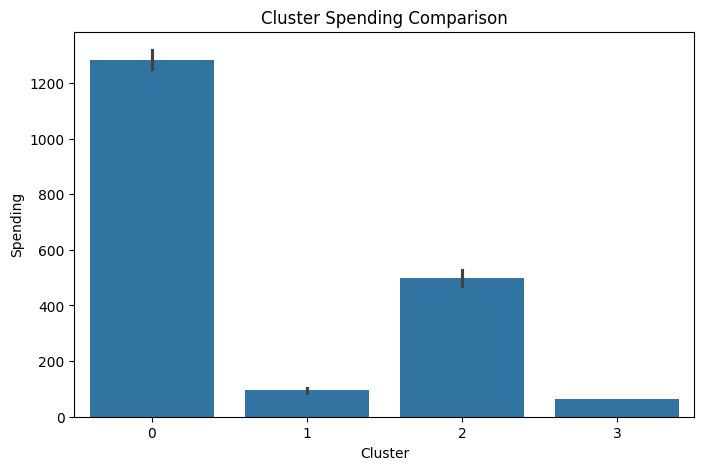

In [71]:
#cluster spending comparsion
plt.figure(figsize=(8,5))

sns.barplot(
    x=df['Cluster'],
    y=df['MntTotal']
)

plt.title("Cluster Spending Comparison")
plt.xlabel("Cluster")
plt.ylabel("Spending")

plt.show()

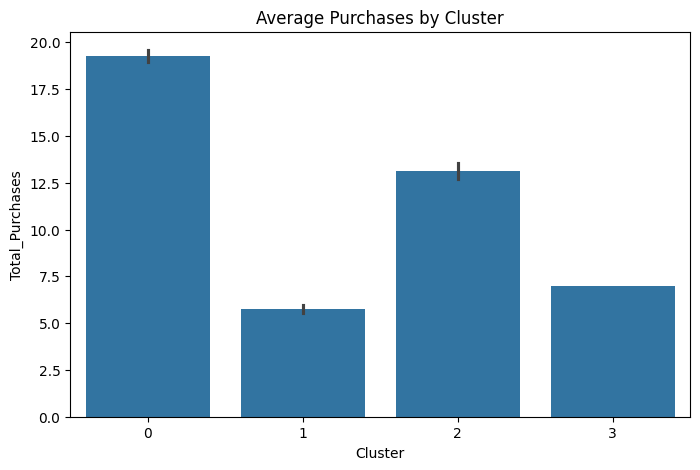

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Cluster',
    y='Total_Purchases'
)

plt.title(
    "Average Purchases by Cluster"
)

plt.show()

In [73]:
print("""
Cluster 0:
High Income, High Spending
Premium Customers

Cluster 1:
Medium Income, Medium Spending
Regular Customers

Cluster 2:
Low Income, Low Spending
Budget Customers

Cluster 3:
High Recency, Low Purchases
At-Risk Customers
""")


Cluster 0:
High Income, High Spending
Premium Customers

Cluster 1:
Medium Income, Medium Spending
Regular Customers

Cluster 2:
Low Income, Low Spending
Budget Customers

Cluster 3:
High Recency, Low Purchases
At-Risk Customers



In [75]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    features,
    df['Cluster']
)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.541


In [76]:
print("""
Silhouette Score Interpretation

Near 1.0  -> Excellent clustering
Near 0.5  -> Good clustering
Near 0.0  -> Overlapping clusters

Higher scores indicate better cluster separation.
""")


Silhouette Score Interpretation

Near 1.0  -> Excellent clustering
Near 0.5  -> Good clustering
Near 0.0  -> Overlapping clusters

Higher scores indicate better cluster separation.



In [77]:
cluster_profile = df.groupby('Cluster')[[
    'Income',
    'Age',
    'MntTotal',
    'Total_Purchases',
    'Recency',
    'Children'
]].mean().round(2)

cluster_profile

,Income,Age,MntTotal,Total_Purchases,Recency,Children
Cluster,,,,,,
0,76967.84,58.57,1283.72,19.25,49.02,0.44
1,28364.25,52.90,94.82,5.76,48.59,1.12
2,52404.66,60.02,499.93,13.12,49.44,1.23
3,666666.00,49.00,62.00,7.00,23.00,1.00


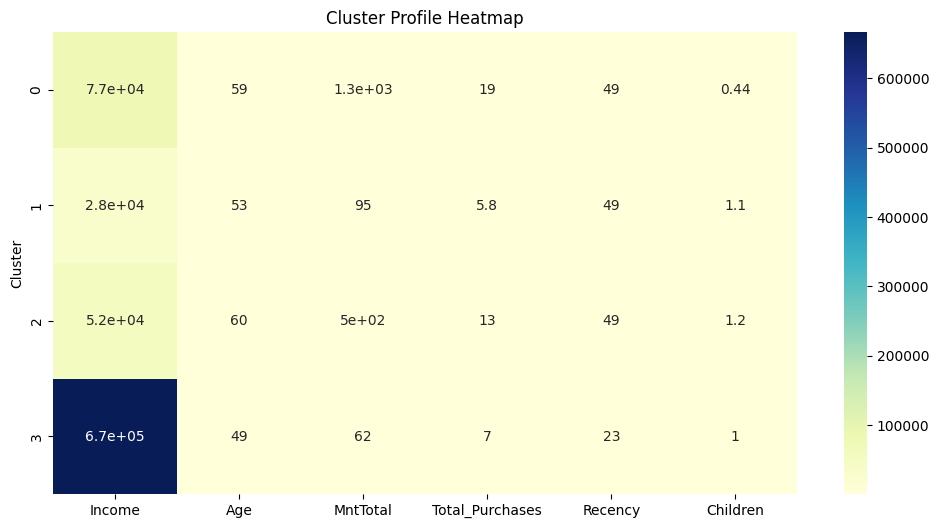

In [78]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Cluster Profile Heatmap")

plt.show()

In [80]:
print("""
MARKETING RECOMMENDATIONS

Cluster 0
-----------
Target with loyalty rewards and premium offers.

Cluster 1
-----------
Provide discounts and promotional bundles.

Cluster 2
-----------
Use personalized email campaigns to increase engagement.

Cluster 3
-----------
Launch reactivation campaigns and special incentives.
""")


MARKETING RECOMMENDATIONS

Cluster 0
-----------
Target with loyalty rewards and premium offers.

Cluster 1
-----------
Provide discounts and promotional bundles.

Cluster 2
-----------
Use personalized email campaigns to increase engagement.

Cluster 3
-----------
Launch reactivation campaigns and special incentives.



In [81]:
segment_summary = df.groupby('Cluster').agg({

    'Income':'mean',
    'MntTotal':'mean',
    'Total_Purchases':'mean',
    'ID':'count'

}).rename(columns={'ID':'Customer_Count'})

segment_summary.round(2)

,Income,MntTotal,Total_Purchases,Customer_Count
Cluster,,,,
0,76967.84,1283.72,19.25,687
1,28364.25,94.82,5.76,742
2,52404.66,499.93,13.12,786
3,666666.00,62.00,7.00,1


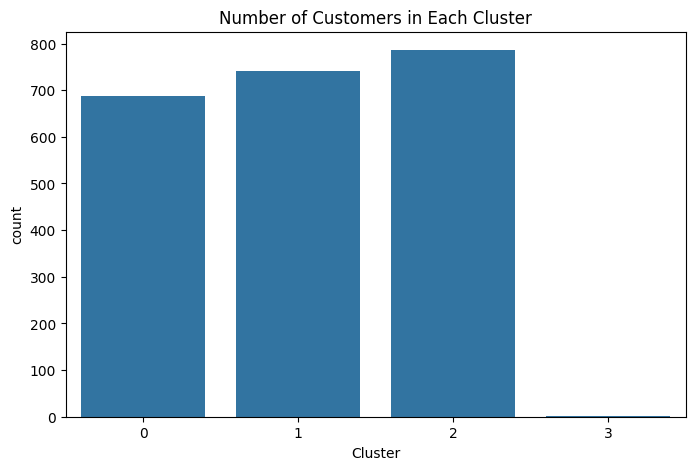

In [82]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Cluster'
)

plt.title("Number of Customers in Each Cluster")

plt.show()